Importing the libaries


In [13]:
import sys
import os

sys.path.append(os.path.abspath("src"))

import gc
import textwrap
import re
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
from transformers import BertTokenizer

import src.train as train_module
from src.model import *
from src.utils import *
from src.train import config
import src.train as train_module


In [14]:
os.makedirs("results/Experiment 1", exist_ok=True)
print("✅ results/Experiment 1 folder ready")

✅ results/Experiment 1 folder ready


Config

In [15]:
flags = config["flags"]

USE_FRAME_AWARE_GROUNDING = flags["use_frame_aware_grounding"]
USE_CONTRASTIVE_ROI = flags["use_contrastive_roi"]
USE_ENTITY_POOLING = flags["use_entity_pooling"]
USE_COT_TEXT = flags["use_cot_text"]

CONTRASTIVE_TAU = config["loss"]["contrastive_tau"]

Setup Device

In [16]:
torch.cuda.empty_cache()
gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Load Dataset

In [17]:
train_dataset = get_storyreasoning_dataset(split="train")
test_dataset = get_storyreasoning_dataset(split="test")

print(train_dataset)
print(train_dataset[0])

Dataset({
    features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
    num_rows: 3552
})
{'story_id': '3920', 'images': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x197900AE3B0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x196D31D3970>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x196B70F3B80>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1971F945990>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1971F944460>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x19791DD1DB0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x19791DD1B70>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x19791DD1AB0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x19791DD1E40>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x197900F02B0>, <PIL.JpegImagePlugin.JpegImageFile

Tokenizer

In [18]:
tokenizer = BertTokenizer.from_pretrained(
    "google-bert/bert-base-uncased"
)

Dataset Preparation

In [19]:
sp_train_dataset = SequencePredictionDataset(train_dataset, tokenizer)
sp_test_dataset = SequencePredictionDataset(test_dataset, tokenizer)

Train/Validation Split

In [20]:
train_size = int(0.8 * len(sp_train_dataset))
val_size = len(sp_train_dataset) - train_size

train_subset, val_subset = random_split(
    sp_train_dataset,
    [train_size, val_size]
)

Dataloaders

In [21]:
train_dataloader = DataLoader(train_subset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_subset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(sp_test_dataset, batch_size=4, shuffle=False)

Model Setup

In [22]:
encoder = EncoderLSTM(tokenizer.vocab_size, 16, 16)
decoder = DecoderLSTM(tokenizer.vocab_size, 16, 16)

text_autoencoder = Seq2SeqLSTM(encoder, decoder)

text_autoencoder, _, _, _ = load_checkpoint(
    text_autoencoder,
    None,
    filename="text_autoencoder.pth"
)

text_autoencoder = text_autoencoder.to(device)

# Freeze text model
for p in text_autoencoder.parameters():
    p.requires_grad = False


visual_autoencoder = VisualAutoencoder(latent_dim=16)
visual_autoencoder.apply(train_module.init_weights)

sequence_predictor = SequencePredictor(
    visual_autoencoder,
    text_autoencoder,
    latent_dim=16,
    gru_hidden_dim=16
).to(device)

optimizer = torch.optim.Adam(sequence_predictor.parameters(), lr=1e-4)

Checkpoint loaded from ./checkpoints\text_autoencoder.pth (epoch 15)


Validation Function

In [23]:
def validation_fn(model, data_loader, device):
    model.eval()

    with torch.no_grad():
        frames, descriptions, image_target, text_target, roi1, roi2, roi_valid, roi_frame, ent_id = next(iter(data_loader))

        frames = frames.to(device)
        descriptions = descriptions.to(device)
        image_target = image_target.to(device)

        pred_img, context_img, _, _, _, _, _ = model(
            frames, descriptions, text_target.to(device)
        )

        fig, ax = plt.subplots(2, 6, figsize=(20, 5))

        for i in range(4):
            show_image(ax[0, i], frames[0, i].cpu())
            ax[0, i].axis("off")

            txt = tokenizer.decode(descriptions[0, i], skip_special_tokens=True)
            ax[1, i].text(0.5, 0.5, textwrap.fill(txt, 40))
            ax[1, i].axis("off")

        show_image(ax[0, 4], image_target[0].cpu())
        ax[0, 4].axis("off")

        show_image(ax[0, 5], context_img[0].cpu())
        ax[0, 5].axis("off")

        plt.tight_layout()
        plt.show()

Training

Epoch [1/10] Loss: 4.5241 (im=0.248, ctx=0.025, txt=2.841)


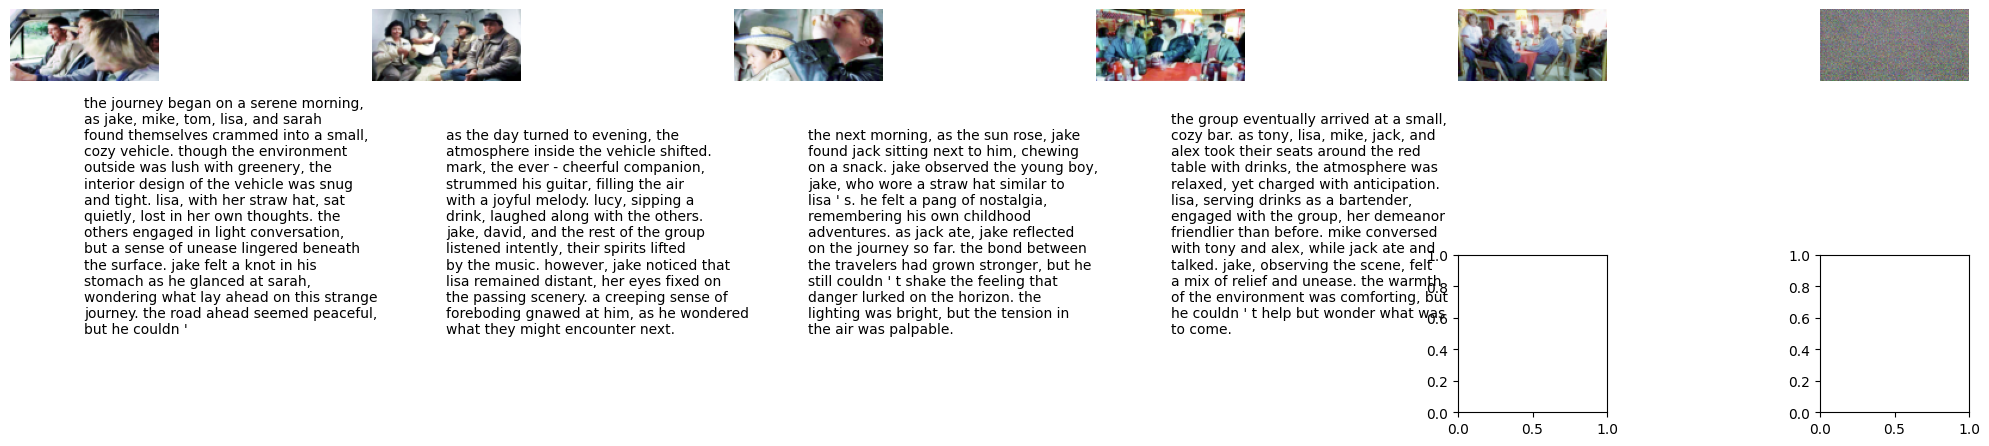

Epoch [2/10] Loss: 4.4285 (im=0.214, ctx=0.053, txt=3.425)


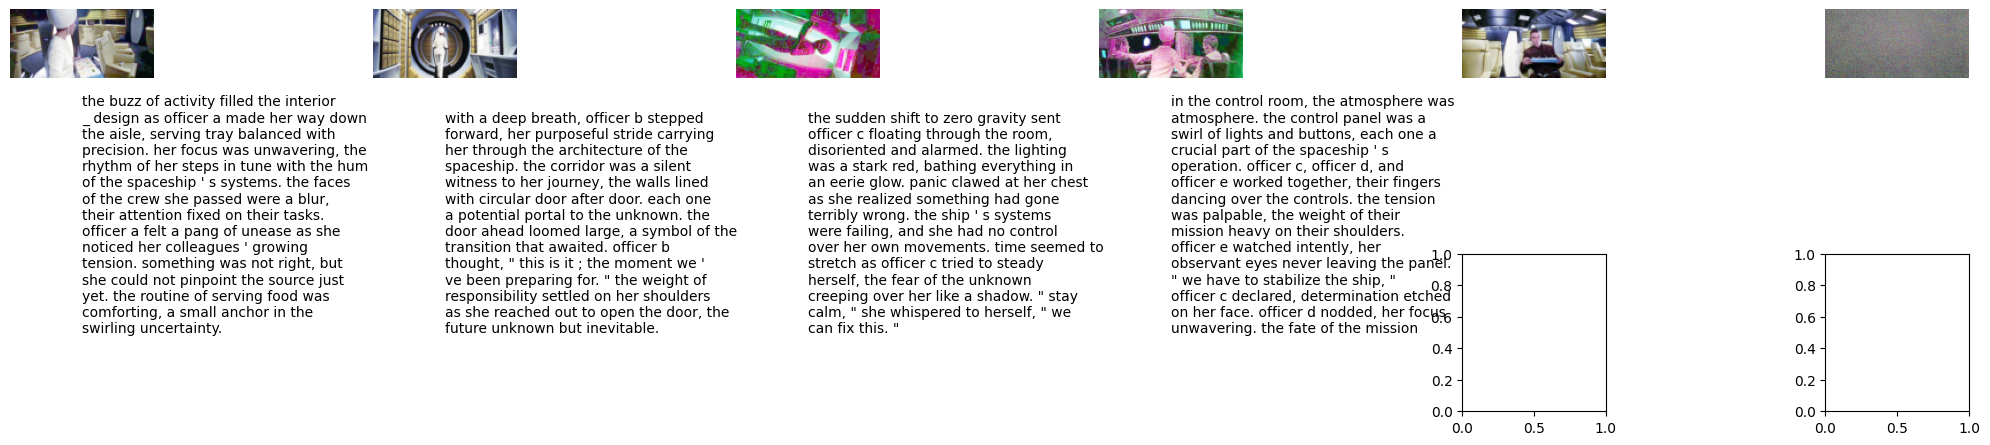

Epoch [3/10] Loss: 4.3889 (im=0.326, ctx=0.026, txt=4.359)


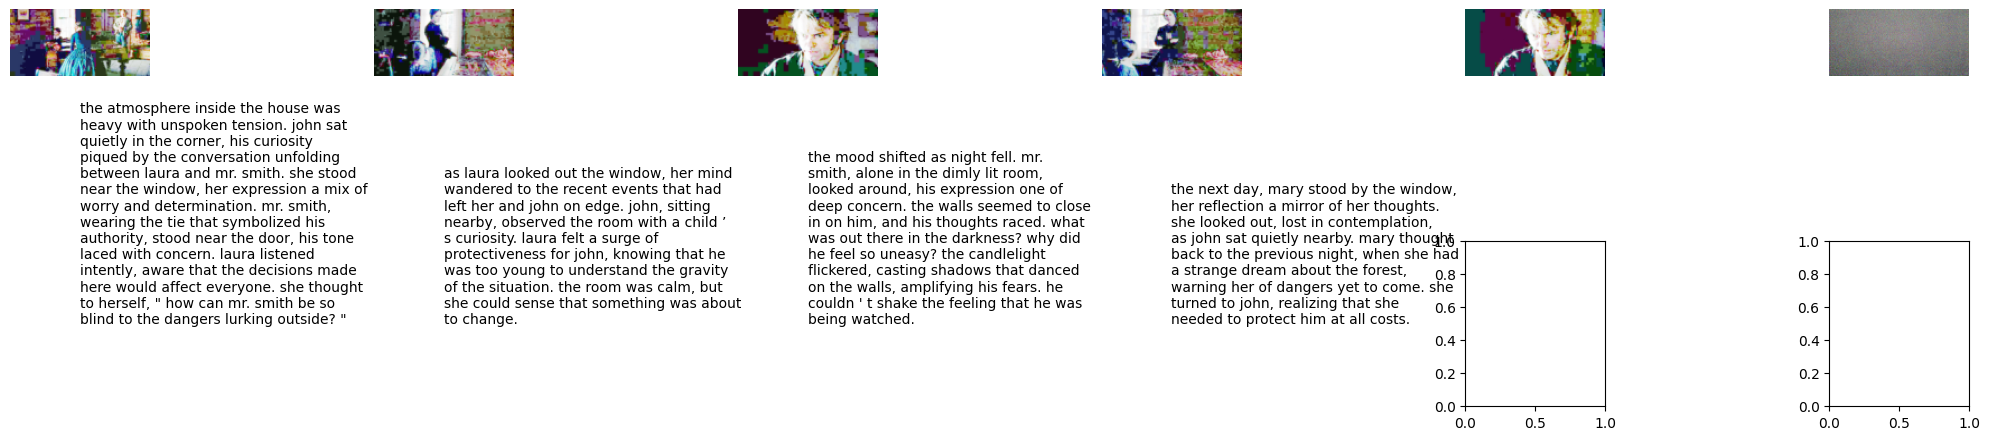

Epoch [4/10] Loss: 4.3772 (im=0.261, ctx=0.032, txt=4.077)


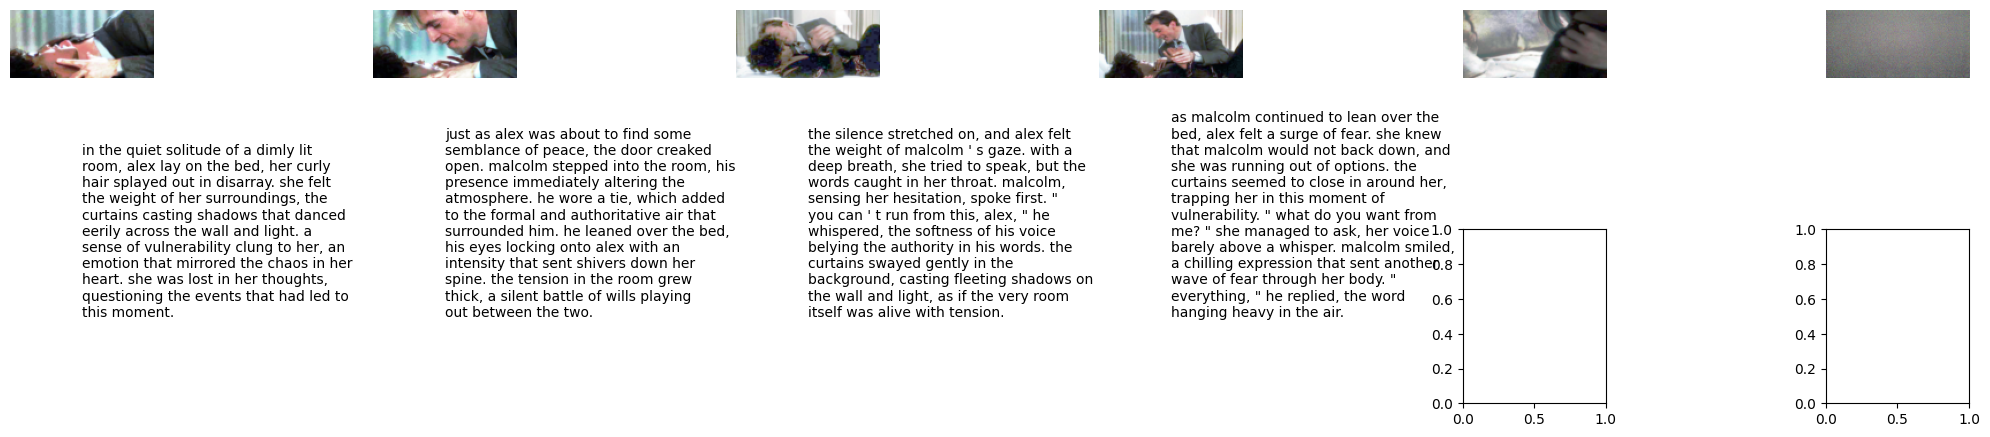

Epoch [5/10] Loss: 4.3668 (im=0.251, ctx=0.022, txt=2.669)


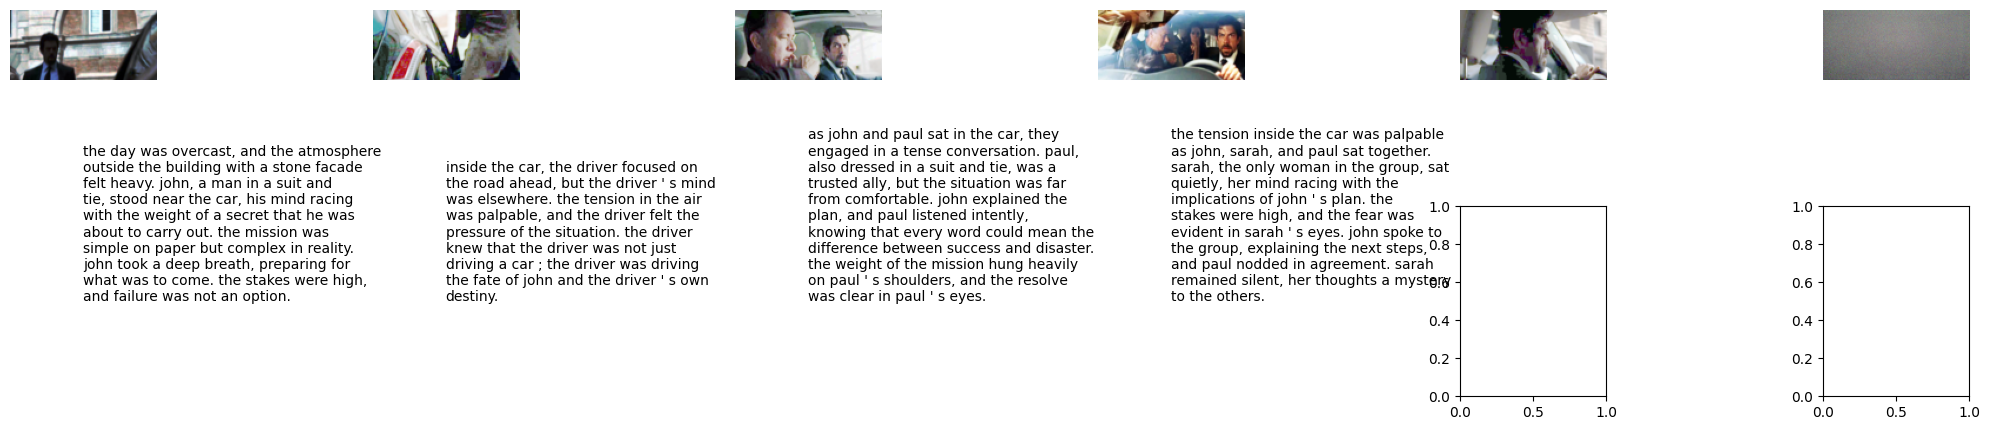

Epoch [6/10] Loss: 4.3697 (im=0.232, ctx=0.018, txt=4.945)


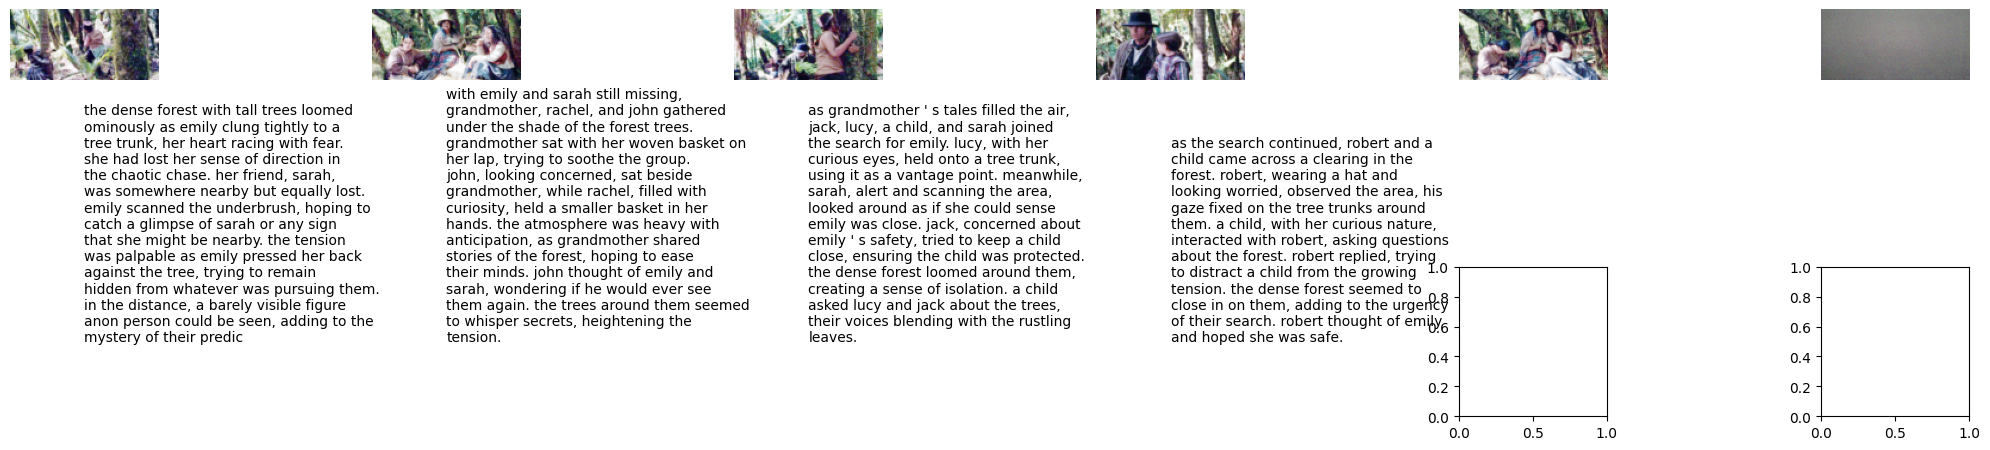

Epoch [7/10] Loss: 4.3691 (im=0.257, ctx=0.037, txt=4.179)


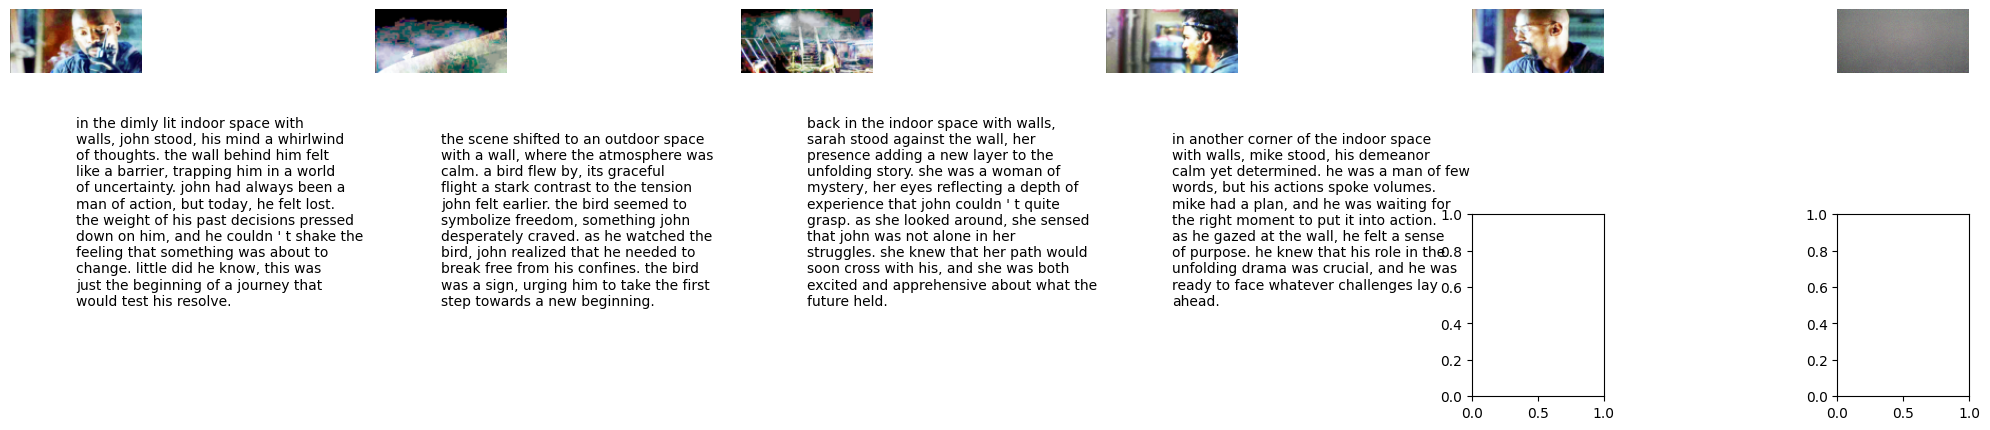

Epoch [8/10] Loss: 4.3609 (im=0.225, ctx=0.016, txt=4.811)


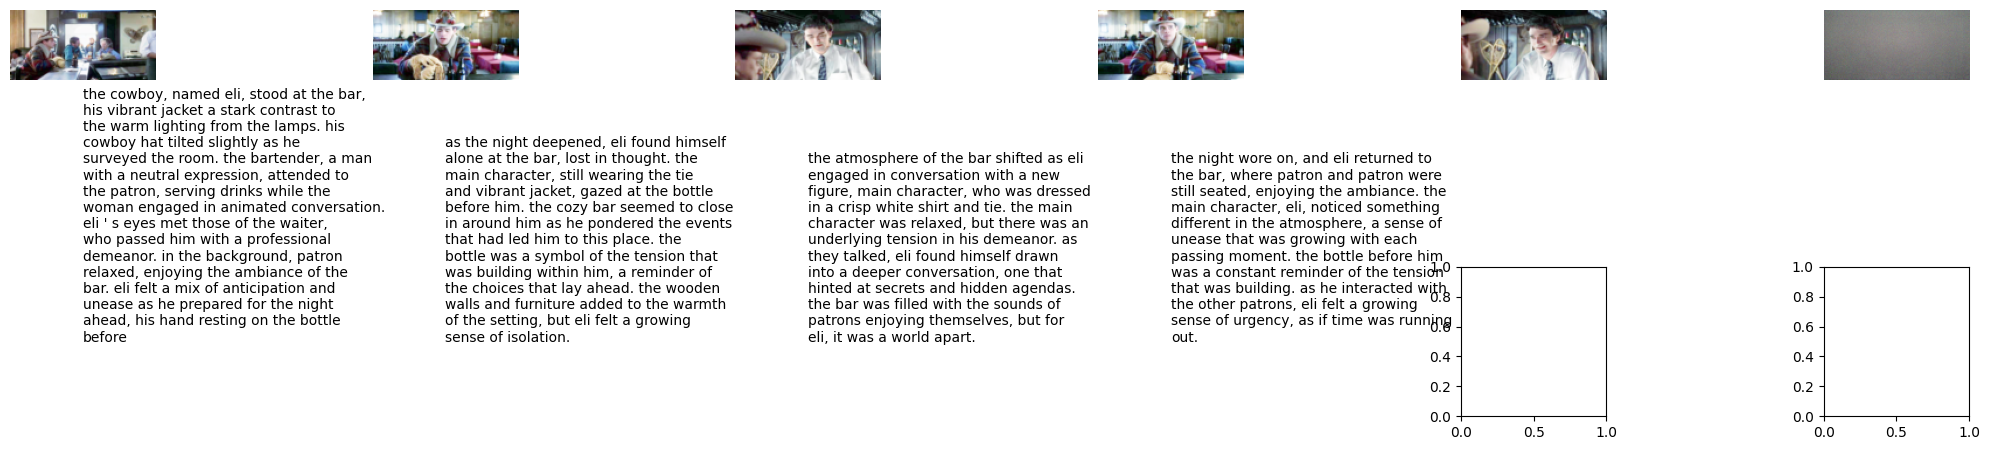

Epoch [9/10] Loss: 4.3634 (im=0.265, ctx=0.031, txt=3.850)


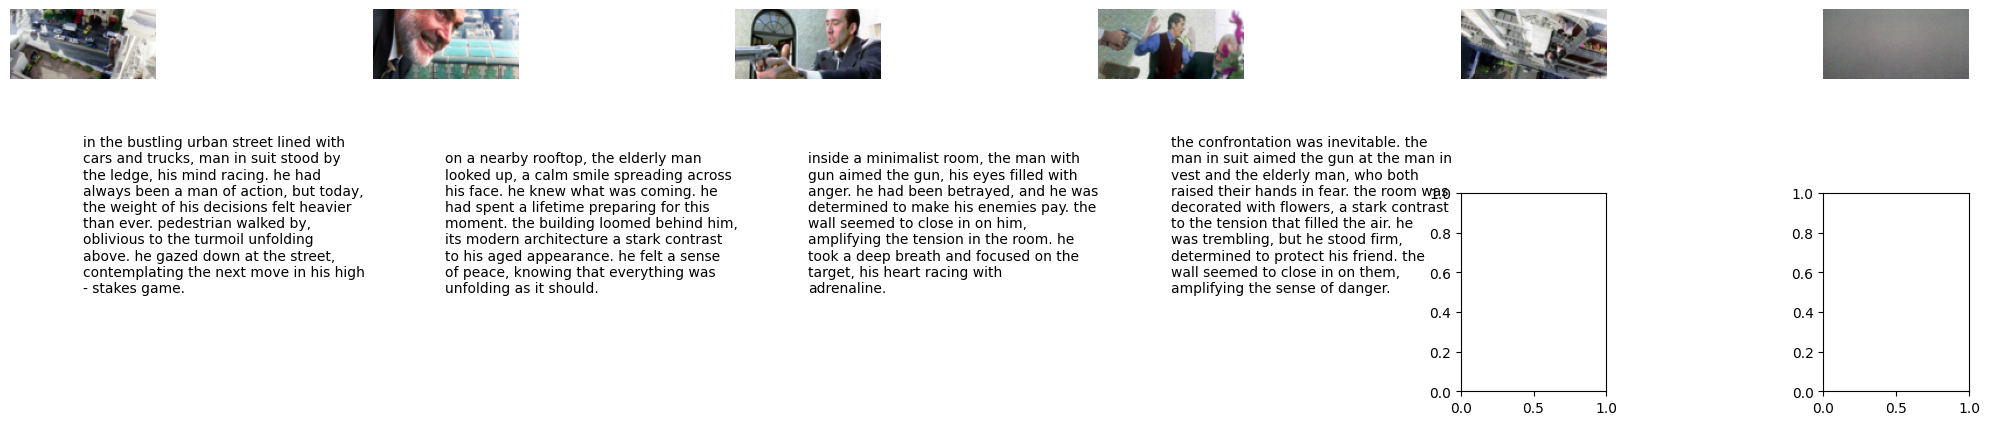

Epoch [10/10] Loss: 4.3605 (im=0.261, ctx=0.023, txt=3.341)


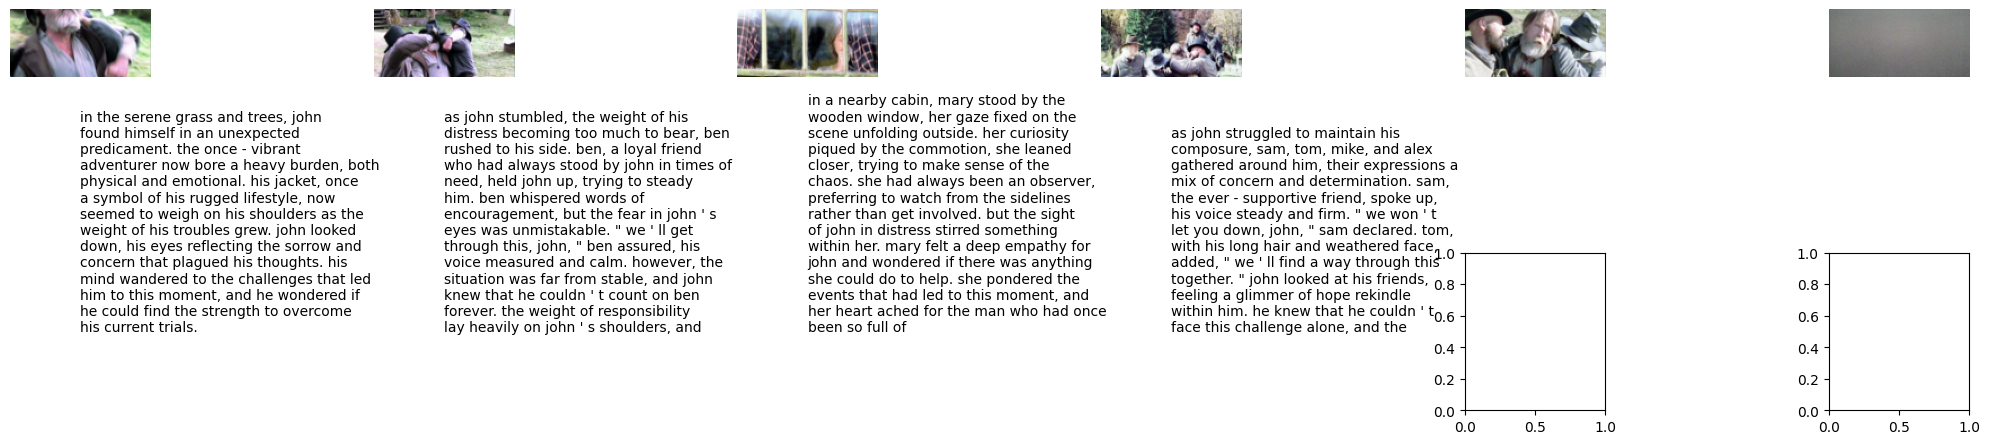

In [24]:
N_EPOCHS = 10

losses = train_module.train_sequence_predictor(
    sequence_predictor,
    train_dataloader,
    val_dataloader,
    optimizer,
    tokenizer,
    device,
    N_EPOCHS,
    validation_fn=validation_fn
)

Saving Training Log (Baseline Experiment)

In [25]:
""""
log_path ="results/baseline/training_log.txt"

with open(log_path, "w") as f:
    for i, loss in enumerate(losses):
        line = f"Epoch {i+1} Loss: {loss: 4f}"
        print(line)
        f.write(line + "\n")

print("Training log saved")
"""

'"\nlog_path ="results/baseline/training_log.txt"\n\nwith open(log_path, "w") as f:\n    for i, loss in enumerate(losses):\n        line = f"Epoch {i+1} Loss: {loss: 4f}"\n        print(line)\n        f.write(line + "\n")\n\nprint("Training log saved")\n'

Experiment 1 - Saving the Training Logs

In [26]:
log_path ="results/Experiment_1/training_log.txt"

with open(log_path, "w") as f:
    for i, loss in enumerate(losses):
        line = f"Epoch {i+1} Loss: {loss: 4f}"
        print(line)
        f.write(line + "\n")

print("Training log saved")

Epoch 1 Loss:  4.524141
Epoch 2 Loss:  4.428547
Epoch 3 Loss:  4.388941
Epoch 4 Loss:  4.377185
Epoch 5 Loss:  4.366778
Epoch 6 Loss:  4.369718
Epoch 7 Loss:  4.369126
Epoch 8 Loss:  4.360948
Epoch 9 Loss:  4.363375
Epoch 10 Loss:  4.360509
Training log saved


Validation Run

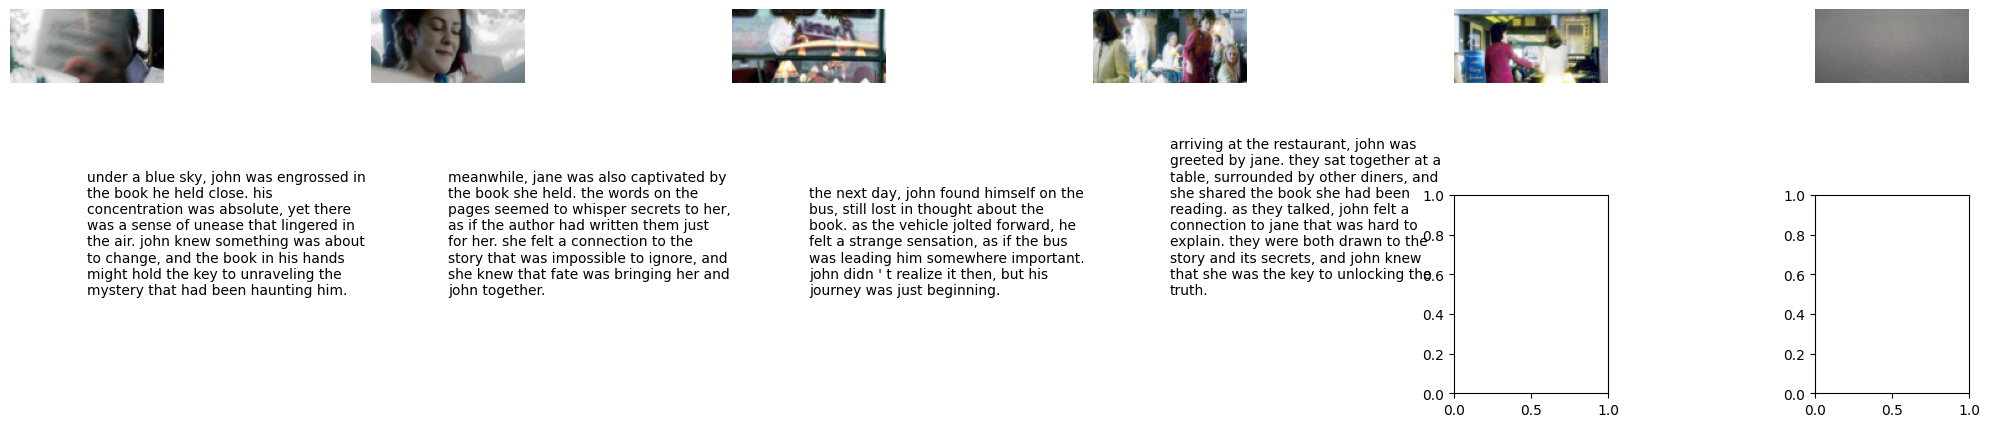

SequencePredictor(
  (image_encoder): VisualEncoder(
    (context_backbone): Backbone(
      (encoder_conv): Sequential(
        (0): Conv2d(3, 16, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (1): GroupNorm(8, 16, eps=1e-05, affine=True)
        (2): LeakyReLU(negative_slope=0.1)
        (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
        (4): GroupNorm(8, 32, eps=1e-05, affine=True)
        (5): LeakyReLU(negative_slope=0.1)
        (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (7): GroupNorm(8, 64, eps=1e-05, affine=True)
        (8): LeakyReLU(negative_slope=0.1)
      )
      (fc1): Sequential(
        (0): Linear(in_features=8192, out_features=16, bias=True)
        (1): ReLU()
      )
    )
    (content_backbone): Backbone(
      (encoder_conv): Sequential(
        (0): Conv2d(3, 16, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (1): GroupNorm(8, 16, eps=1e-05, affine=True)
        (2): LeakyR

In [27]:
validation_fn(sequence_predictor, val_dataloader, device)
sequence_predictor.eval()

Inference

In [28]:
sample = next(iter(val_dataloader))

frames, descriptions, image_target, text_target, *_ = sample

frames = frames.to(device)
descriptions = descriptions.to(device)
text_target = text_target.to(device)

with torch.no_grad():
    pred_img, _, pred_text_logits, *_ = sequence_predictor(
        frames, descriptions, text_target
    )

Decode Predictions

In [29]:
pred_tokens = pred_text_logits.argmax(dim=-1)

pred_sentences = [
    tokenizer.decode(seq.cpu().numpy(), skip_special_tokens=True)
    for seq in pred_tokens
]

true_sentences = [
    tokenizer.decode(seq.cpu().numpy(), skip_special_tokens=True)
    for seq in text_target.squeeze(1)
]

print("\n🔹 Sample Predictions:\n")

for i in range(min(3, len(pred_sentences))):
    print(f"Predicted: {pred_sentences[i]}")
    print(f"Actual   : {true_sentences[i]}")
    print("-" * 50)


🔹 Sample Predictions:

Predicted: the in the room, the, s mind, in the sense, and voice of. the tension situation. the felt s mind to his in the tension, the with, a sense of unease and the. the knew that was a. but the, s voice. about to. the the the room room, a room atmosphere, in he silent witness to the tension. s life. on lighting lighting lighting lighting lighting lightingllllllllllllllllllllllllllrkedrkedrkedrkedrkedrkedrked
Actual   : back at the house, ben ' s sister sat near a barrel, her thoughts consumed by the recent events. ellen ' s brother, standing near the house, watched her with a mix of concern and curiosity. he knew something was wrong, but ben ' s sister was too preoccupied to notice. the large house with its stone wall stood as a silent witness to the family ' s turmoil.
--------------------------------------------------
Predicted: the the stood the, near the room, and, to the, the we was the '. to. the we,, his mind,wavedable. the we ' ' t shake. but he ' to 

Image Output Visualization

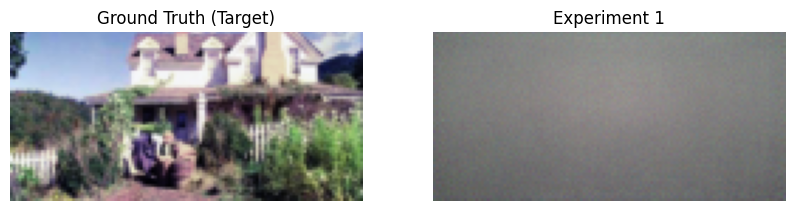

Saved : results/Experiment_1/predictionexample.png,results/Experiment_1/groundtruth.png and results/Experiment_1/visualcomparision.png


In [30]:

# Baseline 
""""
pred_path = "results/baseline/predictionexample.png"
gt_path = "results/baseline/groundtruth.png"
comparision_path= "results/baseline/visualcomparision.png"
"""
# Experiment 1
pred_path = "results/Experiment_1/predictionexample.png"
gt_path = "results/Experiment_1/groundtruth.png"
comparision_path= "results/Experiment_1/visualcomparision.png"

# Prediction Image
plt.imsave(pred_path,pred_img[0].cpu().permute(1, 2, 0).numpy())

# Ground Truth Image
plt.imsave(gt_path,image_target[0].cpu().permute(1,2,0).numpy())

# Side by Side comparision figure
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_target[0].cpu().permute(1,2,0))
plt.title('Ground Truth (Target)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(pred_img[0].cpu().permute(1,2,0))
plt.title('Experiment 1')
plt.axis('off')

plt.savefig(comparision_path)
plt.show()

print(f'Saved : {pred_path},{gt_path} and {comparision_path}')

Loss curve

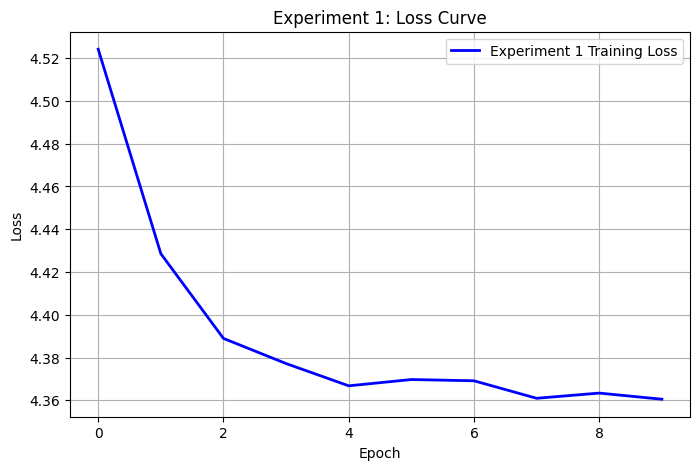

Loss Curve Saved: results/Experiment_1/losscurve.png


In [31]:
# Baseline
# plot_path = "results/baseline/losscurve.png"

# Experiment 1
plot_path = "results/Experiment_1/losscurve.png" 

plt.figure(figsize=(8,5))
plt.plot(losses, label ='Experiment 1 Training Loss', color= 'blue', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 1: Loss Curve")
plt.legend()
plt.grid(True)

# Save for Experiment 1 results
plt.savefig(plot_path)
plt.show()
plt.close()

print(f"Loss Curve Saved: {plot_path}")

Metrics Calculation & Table Saving

In [32]:
from torchmetrics.text.bleu import BLEUScore

# Calculate BLEU-4 Score
bleu_metric = BLEUScore(n_gram=4)
reference = [[s] for s in true_sentences]
experiment1_bleu_val = bleu_metric(pred_sentences,reference).item()

# Results 
print ("\n" + "="*50)
print("Experiment 1 Results ")
print("="*50)
print(f'Final Training Loss: {losses[-1]:.4f}')
print(f"BLEU-4 Accuracy: {experiment1_bleu_val:.4f}")
print("="*50 +"\n")

# Save to metrics.txt

# baseline 
# ----metrics_path = "results/baseline/metrics.txt" ---

# Experiemnt 1
metrics_path = "results/Experiment_1/metrics.txt"
with open(metrics_path, "w") as f:
    f.write("Experiment 1\n")
    f.write("=" *40 + "\n")
    f.write(f"{'Metric':<25} | {'Value':<10}\n")
    f.write("-" * 40 + "\n")
    f.write(f"{'Final Training Loss':<25} | {losses[-1]:.4f}\n")
    f.write(f"{'BLEU-4 Accuracy':<25} | {experiment1_bleu_val:.4f}\n")
    f.write(f"{'Epochs Completed':<25} | {len(losses)}\n")

print(f" Experiment 1 metrics table saved : {metrics_path}")


Experiment 1 Results 
Final Training Loss: 4.3605
BLEU-4 Accuracy: 0.0378

 Experiment 1 metrics table saved : results/Experiment_1/metrics.txt
